In [1]:
# Stock Price Analysis Project
## University of Colombo — Data Science
### Student: Thisara Anupama

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [6]:
# Download TESLA stocks, use format like "DIAL.CM"
ticker = "TSLA"
df = yf.download(ticker, start="2024-01-01", end="2025-12-31")

print("Shape of data:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Shape of data: (501, 5)

First 5 rows:
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
2024-01-02  248.419998  251.250000  244.410004  250.080002  104654200
2024-01-03  238.449997  245.679993  236.320007  244.979996  121082600
2024-01-04  237.929993  242.699997  237.729996  239.250000  102629300
2024-01-05  237.490005  240.119995  234.899994  236.860001   92488900
2024-01-08  240.449997  241.250000  235.300003  236.139999   85166600


In [7]:
# Check the data structure
print("=== DATA INFO ===")
print(df.info())

print("\n=== BASIC STATISTICS ===")
print(df.describe().round(2))

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   501 non-null    float64
 1   (High, TSLA)    501 non-null    float64
 2   (Low, TSLA)     501 non-null    float64
 3   (Open, TSLA)    501 non-null    float64
 4   (Volume, TSLA)  501 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB
None

=== BASIC STATISTICS ===
Price    Close    High     Low    Open        Volume
Ticker    TSLA    TSLA    TSLA    TSLA          TSLA
count   501.00  501.00  501.00  501.00  5.010000e+02
mean    293.23  299.63  286.56  293.24  9.635650e+07
std      94.48   96.41   92.42   94.68  3.390506e+07
min     142.05  144.44  138.80  140.56  3.625290e+07
25%     210.66  215.88  207.56  211.88  7.317800e+07
50%     279.10  284.85  270.78  275.58  8.900020e+07
75%     356.90  362.70  349.16  356.17

In [8]:
# Check date range and column names
print("Date range:", df.index[0], "to", df.index[-1])
print("Columns:", df.columns.tolist())
print("Total trading days:", len(df))

Date range: 2024-01-02 00:00:00 to 2025-12-30 00:00:00
Columns: [('Close', 'TSLA'), ('High', 'TSLA'), ('Low', 'TSLA'), ('Open', 'TSLA'), ('Volume', 'TSLA')]
Total trading days: 501


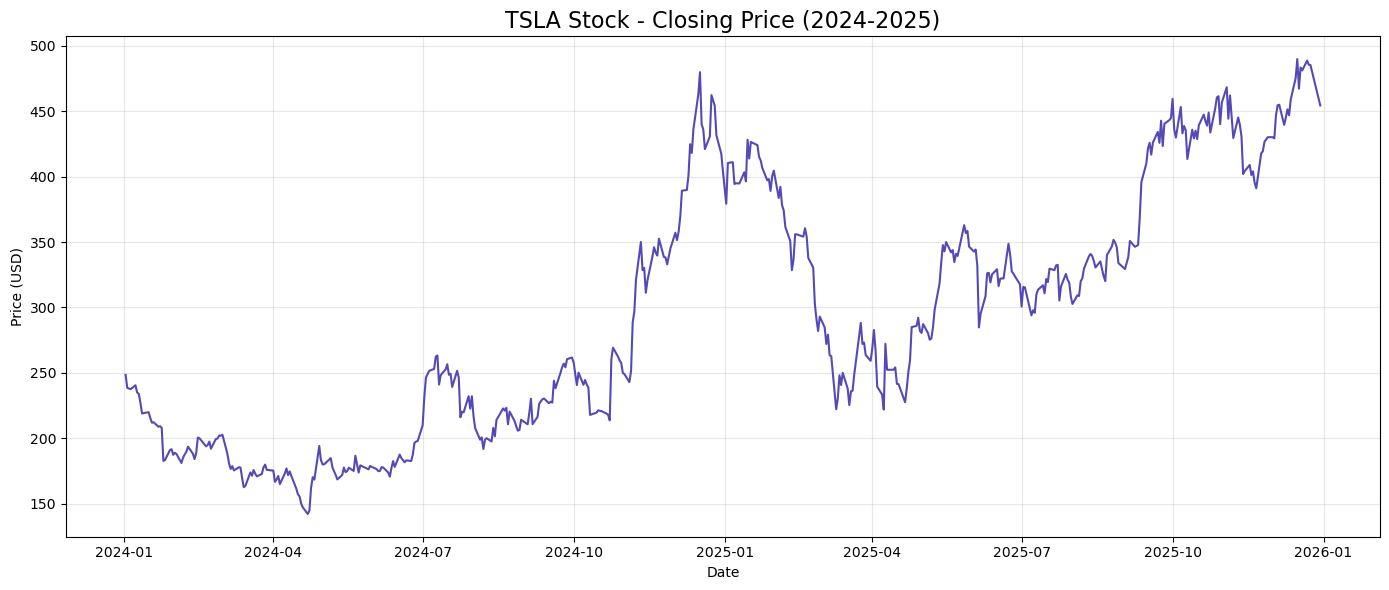

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='#534AB7', linewidth=1.5)
plt.title(f'{ticker} Stock - Closing Price (2024-2025)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_price.png', dpi=150)
plt.show()

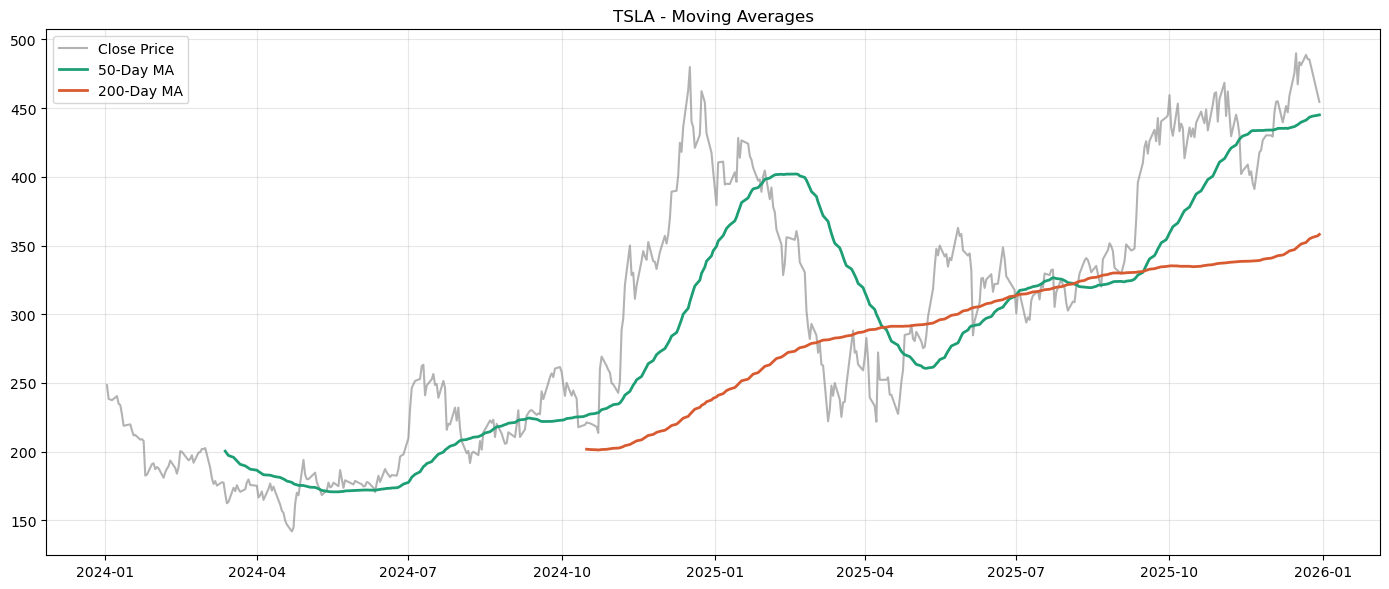

In [11]:
# Moving averages smooth out daily noise
df['MA_50']  = df['Close'].rolling(window=50).mean()   # 50-day
df['MA_200'] = df['Close'].rolling(window=200).mean()  # 200-day

plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.6, color='gray')
plt.plot(df['MA_50'],  label='50-Day MA',  color='#1D9E75', linewidth=2)
plt.plot(df['MA_200'], label='200-Day MA', color='#D85A30', linewidth=2)
plt.title(f'{ticker} - Moving Averages')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

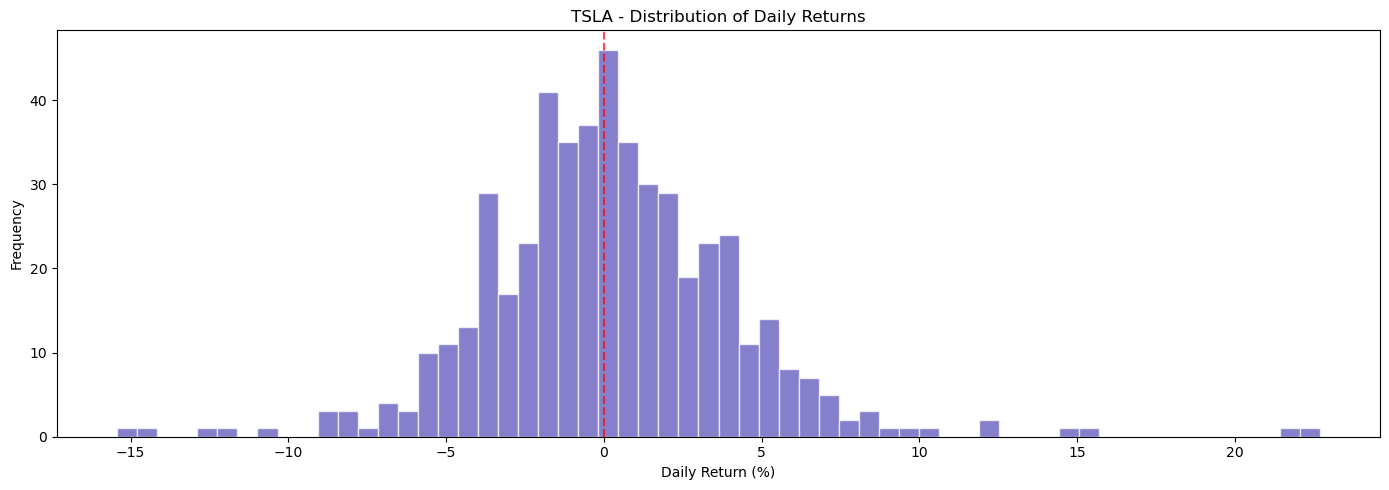

Average daily return: 0.200%
Volatility (std dev): 4.004%


In [12]:
# Daily return = today's change from yesterday (%)
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(14, 5))
plt.hist(df['Daily_Return'].dropna(), bins=60, color='#534AB7', alpha=0.7, edgecolor='white')
plt.title(f'{ticker} - Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Average daily return: {df['Daily_Return'].mean():.3f}%")
print(f"Volatility (std dev): {df['Daily_Return'].std():.3f}%")

In [15]:
# Sharpe Ratio (risk-adjusted return)
risk_free_rate = 0.05 / 252
excess_returns = df['Daily_Return'] / 100 - risk_free_rate
sharpe_ratio = float((excess_returns.mean() / excess_returns.std()) * np.sqrt(252))

# Maximum Drawdown — fixed version
rolling_max = df['Close'].squeeze().cummax()
drawdown = (df['Close'].squeeze() - rolling_max) / rolling_max * 100
max_drawdown = float(drawdown.min())

# Annualized metrics
ann_return = float(df['Daily_Return'].mean() * 252)
ann_volatility = float(df['Daily_Return'].std() * np.sqrt(252))

print("=== RISK METRICS ===")
print(f"Sharpe Ratio:          {sharpe_ratio:.2f}")
print(f"Max Drawdown:          {max_drawdown:.2f}%")
print(f"Annualized Return:     {ann_return:.2f}%")
print(f"Annualized Volatility: {ann_volatility:.2f}%")

=== RISK METRICS ===
Sharpe Ratio:          0.71
Max Drawdown:          -53.77%
Annualized Return:     50.34%
Annualized Volatility: 63.56%


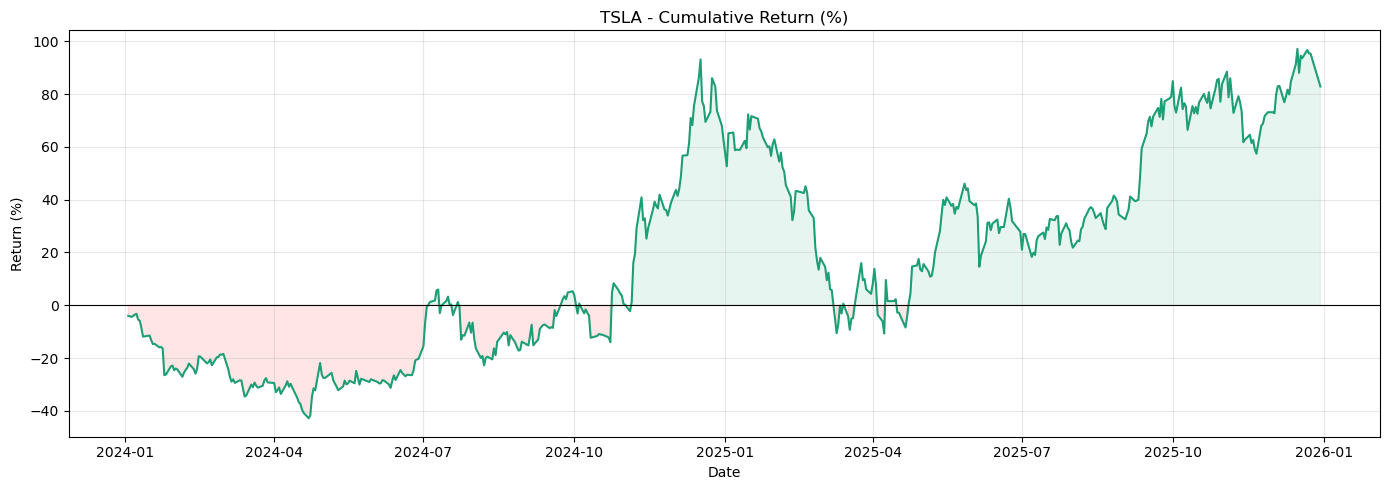

In [16]:
cumulative_return = (1 + df['Daily_Return']/100).cumprod() - 1

plt.figure(figsize=(14, 5))
plt.plot(df.index, cumulative_return * 100, color='#1D9E75', linewidth=1.5)
plt.fill_between(df.index, cumulative_return * 100, 0,
                 where=(cumulative_return >= 0), alpha=0.1, color='#1D9E75')
plt.fill_between(df.index, cumulative_return * 100, 0,
                 where=(cumulative_return < 0), alpha=0.1, color='red')
plt.title(f'{ticker} - Cumulative Return (%)')
plt.xlabel('Date'); plt.ylabel('Return (%)')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()